# Cluster summary matrix — within-cluster positional entropy

For one checkpoint: assign every ISM variant to its GMM cluster, then for each cluster compute the per-position Shannon entropy (bits) of the member sequences. Low entropy = a position the cluster holds fixed (conserved motif); high entropy = a position free to vary. Heatmap: clusters (y) x position (x).

In [2]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT = "peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3"
ADAPTER = 15   # 15bp adapter each side: context for inference/ISM only, NOT attributed and NOT in the 800-D VAE input


class VAE_GMM_eval(nn.Module):
    def __init__(self, D, J, K, hidden, has_dropout):
        super().__init__()
        if has_dropout:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(0.0),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.0))
        else:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, D))
        self.mu_b      = nn.Parameter(torch.zeros(D))
        self.mu_c      = nn.Parameter(torch.zeros(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        self.alpha_raw = nn.Parameter(torch.zeros(K))

    @property
    def alpha(self):
        return F.softplus(self.alpha_raw) + 1e-4


# ----- rebuild model, assign every variant to its hard GMM cluster -----
peak    = CKPT.split(".100k")[0].split(".200k")[0]
lib     = "200k" if ".200k" in CKPT else "100k"
preproc = "znorm" if "znorm" in CKPT else "raw"
suffix  = {"100k": "", "200k": "_200k"}[lib]

sd = torch.load(f"{RESULTS_DIR}/{CKPT}.pt", map_location=DEVICE, weights_only=False)["state_dict"]
model = VAE_GMM_eval(sd["enc.0.weight"].shape[1], sd["enc_mu.weight"].shape[0], sd["mu_c"].shape[0],
                     sd["enc.0.weight"].shape[0], "enc.3.weight" in sd)
model.load_state_dict(sd, strict=False); model.eval().to(DEVICE)

with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
    X = f["ism_centered"][:].reshape(-1, sd["enc.0.weight"].shape[1]).astype(np.float32)
if preproc == "znorm":
    X = (X - X.mean()) / (X.std() + 1e-8)

alpha = model.alpha
Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())
lv_c, mu_c = model.log_var_c[None], model.mu_c[None]
with torch.no_grad():
    h = model.enc(torch.from_numpy(X).to(DEVICE))
    mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
    KL_k = 0.5 * (lv_c - lv_z + (torch.exp(lv_z) + (mu_z - mu_c)**2) * torch.exp(-lv_c) - 1.0).sum(-1)
    hard = (Elog_pi[None] - KL_k).argmax(1).cpu().numpy()

# ----- per-cluster per-position entropy of the member one-hot sequences (core only, adapters cropped) -----
with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    onehot = f["sequences"][:][:, ADAPTER:-ADAPTER]        # (N, 200, 4) core, aligned to attribution positions 0..199

alive = sorted(np.unique(hard), key=lambda k: (hard == k).sum(), reverse=True)   # largest first
entropy = np.zeros((len(alive), onehot.shape[1]))
for i, k in enumerate(alive):
    p = onehot[hard == k].mean(0)                           # (L, 4) base frequencies
    entropy[i] = -(p * np.log2(p + 1e-12)).sum(1)           # (L,) bits, 0..2
print(f"{CKPT}\n{len(alive)} clusters x {onehot.shape[1]} positions")

peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3
20 clusters x 200 positions


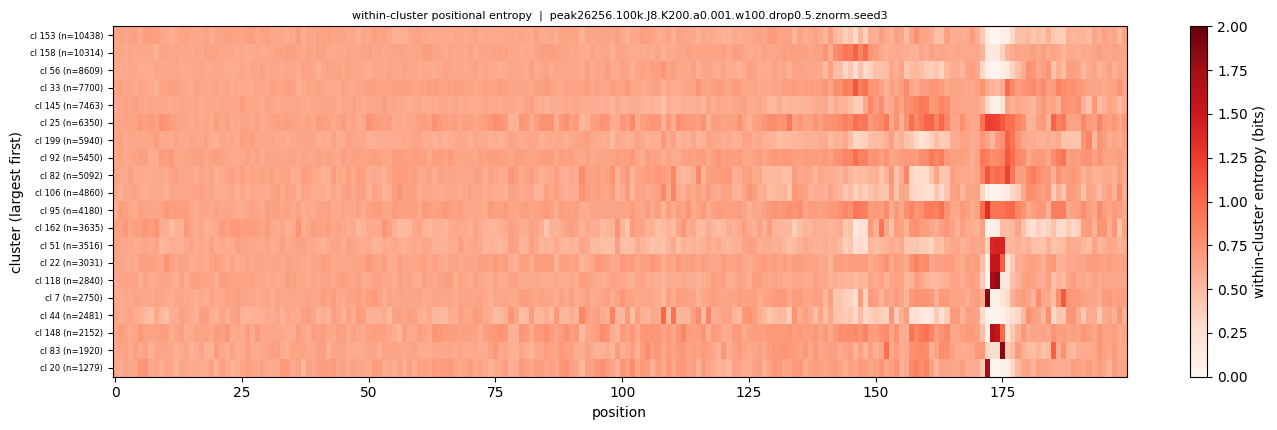

In [3]:
plt.figure(figsize=(14, max(4, 0.22 * len(alive))))
plt.imshow(entropy, aspect="auto", cmap="Reds", vmin=0, vmax=2, interpolation="nearest")
plt.colorbar(label="within-cluster entropy (bits)")
plt.yticks(range(len(alive)), [f"cl {k} (n={(hard == k).sum()})" for k in alive], fontsize=6)
plt.xlabel("position"); plt.ylabel("cluster (largest first)")
plt.title(f"within-cluster positional entropy  |  {CKPT}", fontsize=8)
plt.tight_layout(); plt.show()

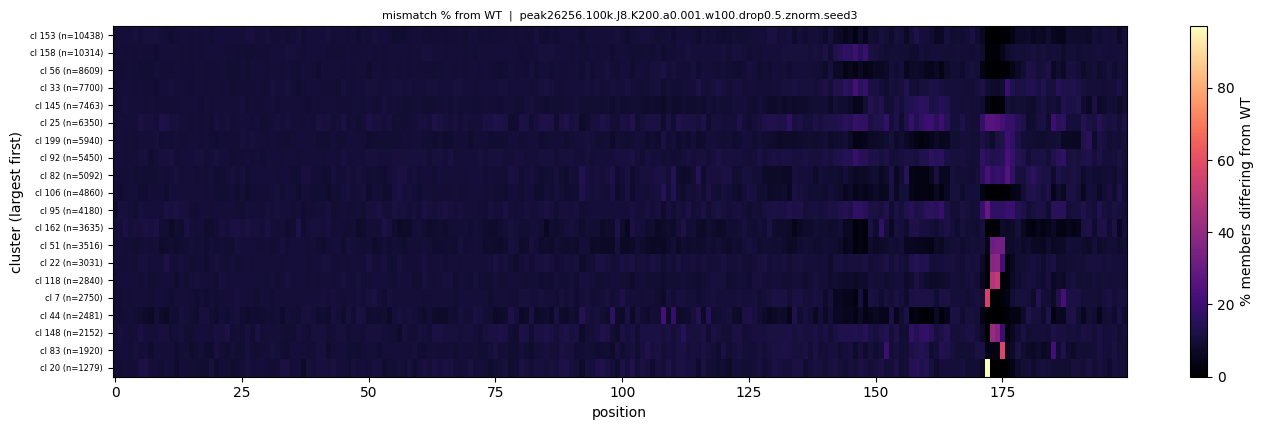

In [4]:
# ----- same matrix but mismatch % from WT: fraction of members differing from the WT base per position -----
with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{suffix}/{peak}.h5") as f:
    wt_seq = f["wt_sequence"][:][ADAPTER:-ADAPTER].argmax(1)   # (200,) WT base per core position
mism_all = onehot.argmax(2) != wt_seq                       # (N, 200) does variant differ from WT here

mismatch = np.zeros((len(alive), onehot.shape[1]))
for i, k in enumerate(alive):
    mismatch[i] = mism_all[hard == k].mean(0) * 100         # (L,) % of members mutated vs WT

plt.figure(figsize=(14, max(4, 0.22 * len(alive))))
plt.imshow(mismatch, aspect="auto", cmap="magma", vmin=0, interpolation="nearest")
plt.colorbar(label="% members differing from WT")
plt.yticks(range(len(alive)), [f"cl {k} (n={(hard == k).sum()})" for k in alive], fontsize=6)
plt.xlabel("position"); plt.ylabel("cluster (largest first)")
plt.title(f"mismatch % from WT  |  {CKPT}", fontsize=8)
plt.tight_layout(); plt.show()

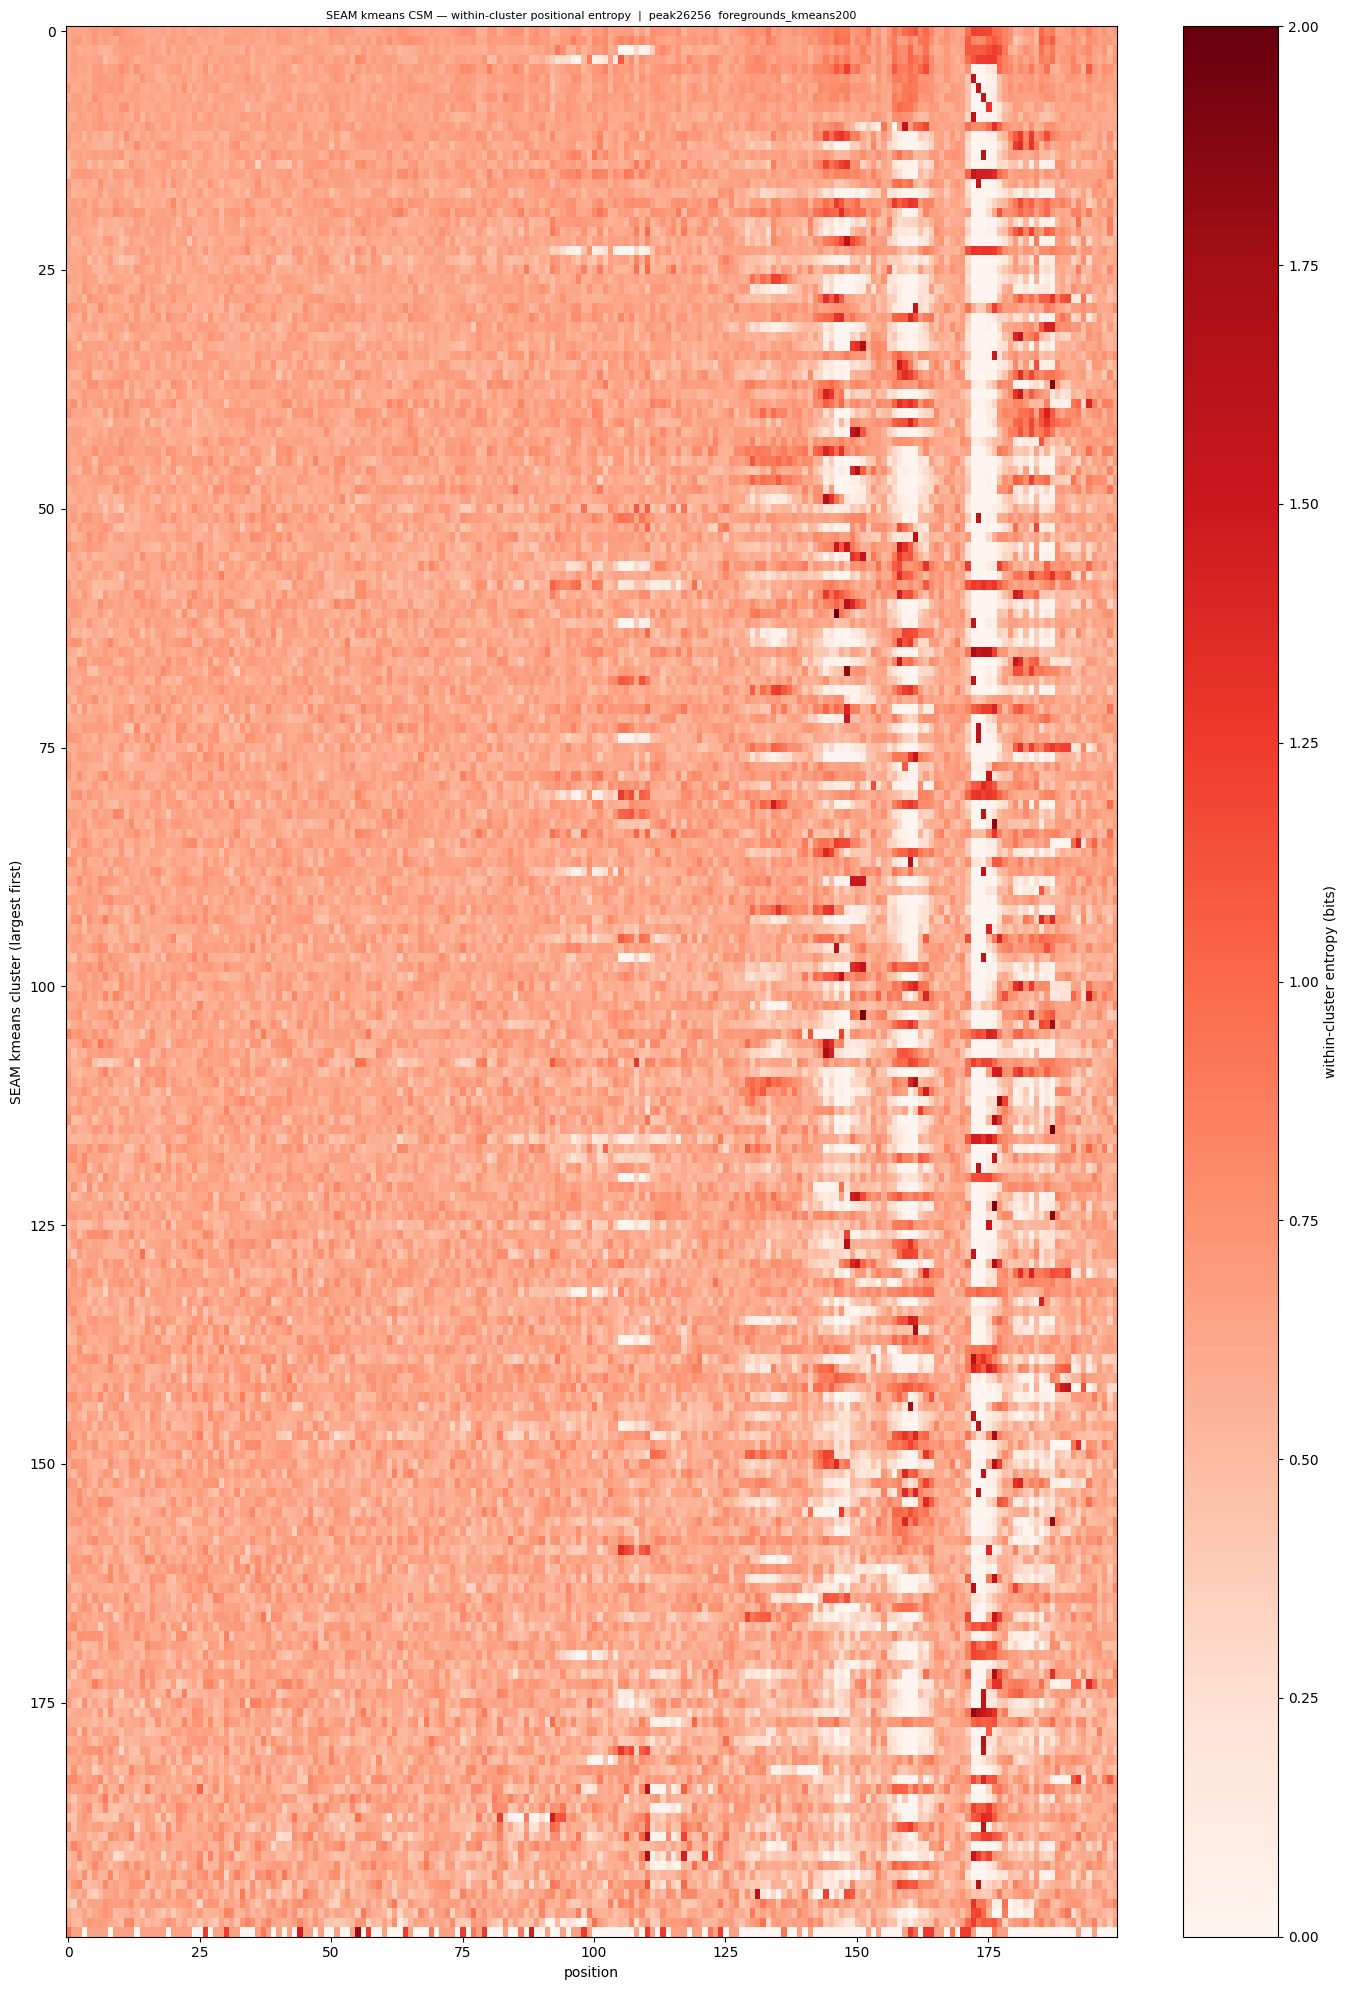

In [5]:
# ----- SEAM's own kmeans clustering: same within-cluster entropy CSM, for comparison -----
SEAM_KM = "foregrounds_kmeans200"                          # precomputed SEAM kmeans on the same library (swap K here)
km = np.load(f"{SEAM_DIR}/{SEAM_KM}/{peak}/cluster_labels.npy")   # (N,) kmeans cluster per variant, adapter-free

alive_km = sorted(np.unique(km), key=lambda c: (km == c).sum(), reverse=True)
ent_km = np.zeros((len(alive_km), onehot.shape[1]))
for i, c in enumerate(alive_km):
    p = onehot[km == c].mean(0)
    ent_km[i] = -(p * np.log2(p + 1e-12)).sum(1)

plt.figure(figsize=(14, min(20, max(4, 0.22 * len(alive_km)))))
plt.imshow(ent_km, aspect="auto", cmap="Reds", vmin=0, vmax=2, interpolation="nearest")
plt.colorbar(label="within-cluster entropy (bits)")
if len(alive_km) <= 60:
    plt.yticks(range(len(alive_km)), [f"km {c} (n={(km == c).sum()})" for c in alive_km], fontsize=6)
plt.xlabel("position"); plt.ylabel("SEAM kmeans cluster (largest first)")
plt.title(f"SEAM kmeans CSM — within-cluster positional entropy  |  {peak}  {SEAM_KM}", fontsize=8)
plt.tight_layout(); plt.show()

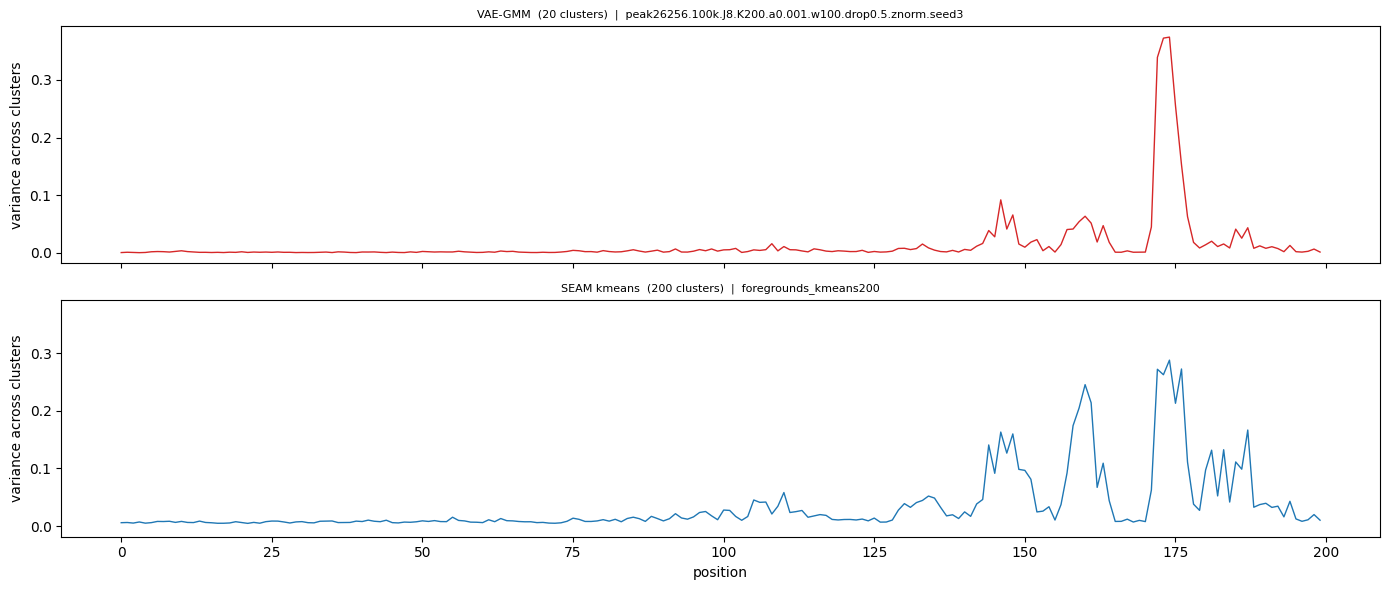

In [7]:
# ----- collapse each CSM to one scalar per position: variance of entropy across clusters -----
# high variance = clusters disagree about whether that position is conserved -> position discriminates mechanisms
var_vae = entropy.var(0)                                    # (200,)
var_km  = ent_km.var(0)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
axes[0].plot(var_vae, color="C3", lw=1)
axes[0].set_title(f"VAE-GMM  ({len(alive)} clusters)  |  {CKPT}", fontsize=8)
axes[1].plot(var_km, color="C0", lw=1)
axes[1].set_title(f"SEAM kmeans  ({len(alive_km)} clusters)  |  {SEAM_KM}", fontsize=8)
for ax in axes:
    ax.set_ylabel("variance across clusters")
axes[1].set_xlabel("position")
plt.tight_layout(); plt.show()

In [8]:
# ----- every config: Pearson r between its positional-variance profile and its peak's SEAM kmeans200 profile -----
import os, glob, pandas as pd
from scipy.stats import pearsonr

CSV = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/visualize/results/csm_var_pearson.csv"
ckpts = sorted(os.path.basename(p)[:-3] for p in glob.glob(f"{RESULTS_DIR}/*.pt"))
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame(columns=["ckpt", "peak", "J", "n_clusters", "r"])
todo = [c for c in ckpts if c not in set(done.ckpt)]
print(f"{len(done)} cached, {len(todo)} to compute")

onehot_cache, X_cache, seam_cache, rows = {}, {}, {}, []
for c in todo:
    pk   = c.split(".100k")[0].split(".200k")[0]
    sfx  = "_200k" if ".200k" in c else ""
    prep = "znorm" if "znorm" in c else "raw"

    if (pk, sfx) not in onehot_cache:
        with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{sfx}/{pk}.h5") as f:
            onehot_cache[pk, sfx] = f["sequences"][:][:, ADAPTER:-ADAPTER]
        km = np.load(f"{SEAM_DIR}/foregrounds{sfx}_kmeans200/{pk}/cluster_labels.npy")
        oh = onehot_cache[pk, sfx]
        ent = np.stack([-(p * np.log2(p + 1e-12)).sum(1) for p in
                        (oh[km == k].mean(0) for k in np.unique(km))])
        seam_cache[pk, sfx] = ent.var(0)
    if (pk, sfx, prep) not in X_cache:
        with h5py.File(f"{SEAM_DIR}/ism{sfx}/{pk}.h5") as f:
            Xc = f["ism_centered"][:].reshape(f["ism_centered"].shape[0], -1).astype(np.float32)
        X_cache[pk, sfx, prep] = (Xc - Xc.mean()) / (Xc.std() + 1e-8) if prep == "znorm" else Xc

    sd = torch.load(f"{RESULTS_DIR}/{c}.pt", map_location=DEVICE, weights_only=False)["state_dict"]
    m = VAE_GMM_eval(sd["enc.0.weight"].shape[1], sd["enc_mu.weight"].shape[0], sd["mu_c"].shape[0],
                     sd["enc.0.weight"].shape[0], "enc.3.weight" in sd)
    m.load_state_dict(sd, strict=False); m.eval().to(DEVICE)
    Elog_pi = torch.digamma(m.alpha) - torch.digamma(m.alpha.sum())
    with torch.no_grad():
        h = m.enc(torch.from_numpy(X_cache[pk, sfx, prep]).to(DEVICE))
        mz, lz = m.enc_mu(h)[:, None, :], m.enc_lv(h)[:, None, :]
        KL_k = 0.5 * (m.log_var_c[None] - lz + (torch.exp(lz) + (mz - m.mu_c[None])**2)
                      * torch.exp(-m.log_var_c[None]) - 1.0).sum(-1)
        hd = (Elog_pi[None] - KL_k).argmax(1).cpu().numpy()

    oh = onehot_cache[pk, sfx]
    ent_v = np.stack([-(p * np.log2(p + 1e-12)).sum(1) for p in
                      (oh[hd == k].mean(0) for k in np.unique(hd))])
    r = pearsonr(ent_v.var(0), seam_cache[pk, sfx])[0]
    rows.append(dict(ckpt=c, peak=pk, J=sd["enc_mu.weight"].shape[0], n_clusters=len(np.unique(hd)), r=r))
    print(f"{c}  r={r:.3f}")

if rows:
    done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
    os.makedirs(os.path.dirname(CSV), exist_ok=True)
    done.to_csv(CSV, index=False)
done.sort_values("r", ascending=False)

0 cached, 69 to compute
peak26256.100k.J16.K200.a0.001.bgvarD.seed3  r=0.940
peak26256.100k.J16.K200.a0.001.w30.seed3  r=0.970
peak26256.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  r=0.986
peak26256.100k.J32.K200.a0.001.seed3  r=0.969
peak26256.100k.J4.K200.a0.001.w100.drop0.5.raw.bgre.seed33  r=0.971
peak26256.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  r=0.930
peak26256.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3  r=0.975
peak26256.100k.J8.K200.a0.001.w100.drop0.5.raw.bgre.seed33  r=0.958
peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3  r=0.827
peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3  r=0.798
peak26256.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3  r=0.901
peak26256.100k.J8.K200.a0.001.w30.seed3  r=0.973
peak26256.100k.J8.K200.a0.001.w50.drop0.3.seed3  r=0.971
peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.bgre.seed3  r=0.888
peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3  r=0.906
peak26256.100k.J8.K200.a0.001.w50.drop0.5.raw.bgre.s

/tmp/ipykernel_920350/2768941361.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)


,ckpt,peak,J,n_clusters,r
2,peak26256.100k.J16.K200.a0.001.w50.drop0.3.zno...,peak26256,16,174,0.985703
28,peak27535_Reversed.100k.J32.K200.a0.001.warm30...,peak27535_Reversed,32,198,0.985208
50,peak84030.100k.J32.K200.a0.001.seed3,peak84030,32,200,0.975553
18,peak26256.100k.J8.K200.a0.001.w50.seed3,peak26256,8,198,0.975100
6,peak26256.100k.J4.K200.a0.001.w50.drop0.5.znor...,peak26256,4,199,0.974787
...,...,...,...,...,...
43,peak27535_Reversed.100k.J8.K200.a0.001.w60.dro...,peak27535_Reversed,8,31,0.780528
33,peak27535_Reversed.100k.J8.K200.a0.001.w100.dr...,peak27535_Reversed,8,22,0.780426
34,peak27535_Reversed.100k.J8.K200.a0.001.w100.dr...,peak27535_Reversed,8,23,0.759498
39,peak27535_Reversed.100k.J8.K200.a0.001.w50.dro...,peak27535_Reversed,8,32,0.756914


22 configs shared across all 3 peaks


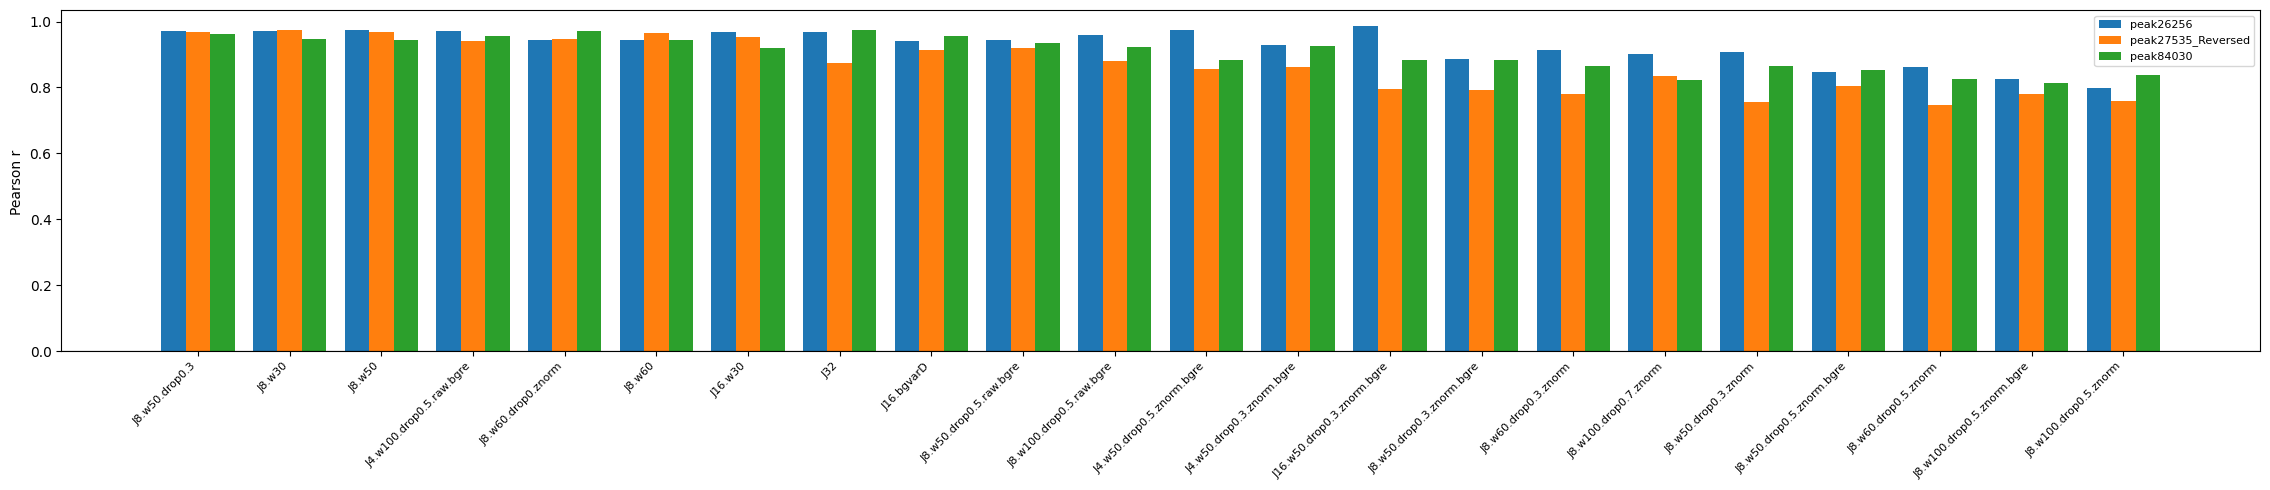

In [13]:
# ----- only configs trained on every peak, so the comparison is like-for-like -----
done["config"] = done.ckpt.str.replace(r"^.*?\.100k\.|\.K200\.a0\.001|\.seed\d+$", "", regex=True)
M = done.pivot_table(index="config", columns="peak", values="r").dropna()
M = M.loc[M.mean(1).sort_values(ascending=False).index]
print(f"{len(M)} configs shared across all {M.shape[1]} peaks")

x = np.arange(len(M))
w = 0.8 / M.shape[1]
plt.figure(figsize=(0.9 * len(M) + 3, 5))
for j, pk in enumerate(M.columns):
    plt.bar(x + j * w, M[pk], width=w, color=plt.cm.tab10(j), label=pk)
plt.xticks(x + 0.4 - w / 2, M.index, rotation=45, ha="right", fontsize=8)
plt.axhline(0, color="k", lw=0.8)
plt.ylabel("Pearson r ")
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()